# Import Libraries

In [1]:
# ============================================================
#               IMPORT REQUIRED LIBRARIES
# ============================================================

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

# Model Saving
import joblib

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Dataset

In [3]:
df = pd.read_csv("emails.csv")  

print("Dataset Loaded Successfully")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows    : 5172
Columns : 3002


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


# Dataset Exploration

In [6]:
print("DATASET INFORMATION")

print("="*60)

print(f"Shape               : {df.shape}")
print(f"Duplicate Rows      : {df.duplicated().sum()}")
print(f"Missing Values      : {df.isnull().sum().sum()}")

print("="*60)

print("\nData Types\n")
display(df.dtypes.value_counts())

print("="*60)

print("\nFirst Five Rows Are\n")
display(df.head())

print("="*60)

print("\nStatistical Summary\n")
display(df.describe().T.head(10))

DATASET INFORMATION
Shape               : (5172, 3002)
Duplicate Rows      : 0
Missing Values      : 0

Data Types



int64     3001
object       1
Name: count, dtype: int64


First Five Rows Are



,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Statistical Summary



,count,mean,std,min,25%,50%,75%,max
the,5172.0,6.640565,11.745009,0.0,0.0,3.0,8.00,210.0
to,5172.0,6.188128,9.534576,0.0,1.0,3.0,7.00,132.0
ect,5172.0,5.143852,14.101142,1.0,1.0,1.0,4.00,344.0
and,5172.0,3.075599,6.045970,0.0,0.0,1.0,3.00,89.0
for,5172.0,3.124710,4.680522,0.0,1.0,2.0,4.00,47.0
of,5172.0,2.627030,6.229845,0.0,0.0,1.0,2.00,77.0
a,5172.0,55.517401,87.574172,0.0,12.0,28.0,62.25,1898.0
you,5172.0,2.466551,4.314444,0.0,0.0,1.0,3.00,70.0
hou,5172.0,2.024362,6.967878,0.0,0.0,0.0,1.00,167.0
in,5172.0,10.600155,19.281892,0.0,1.0,5.0,12.00,223.0


# Data Cleaning

In [4]:
# Remove identifier column
if "Email No." in df.columns:
    df.drop("Email No.", axis=1, inplace=True)

# Check duplicates
duplicates = df.duplicated().sum()

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows.")
else:
    print("No duplicate rows found.")

print("Final Dataset Shape :", df.shape)

Removed 541 duplicate rows.
Final Dataset Shape : (4631, 3001)


# Exploratory Data Analysis (EDA)

In [11]:
print("\nDataset Exploration.\n")

summary = pd.DataFrame({
    "Metric": [
        "Number of Samples",
        "Number of Features",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        df.shape[0],
        df.shape[1]-1,
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

display(summary)


Dataset Exploration.



,Metric,Value
0,Number of Samples,5172
1,Number of Features,3001
2,Missing Values,0
3,Duplicate Rows,0



TARGET VARIABLE DISTRIBUTION



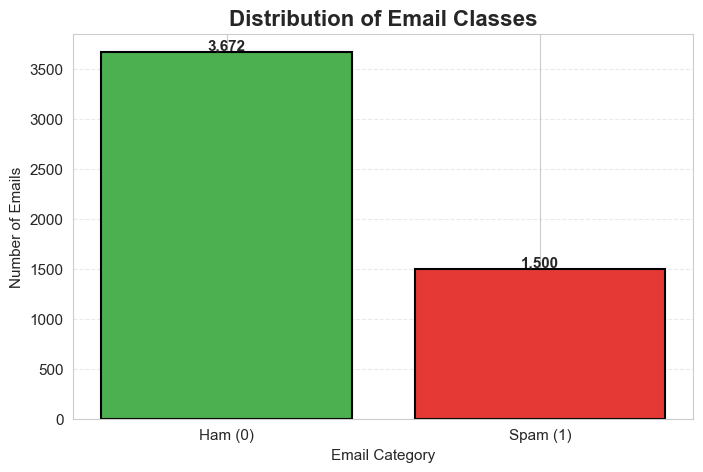

In [16]:
print("\nTARGET VARIABLE DISTRIBUTION\n")

target_counts = df["Prediction"].value_counts().sort_index()

colors = ["#4CAF50", "#E53935"]

plt.figure(figsize=(8,5))

bars = plt.bar(
    ["Ham (0)", "Spam (1)"],
    target_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

plt.title("Distribution of Email Classes",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Email Category")

plt.ylabel("Number of Emails")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+20,
        f"{int(height):,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.show()

Class Distribution



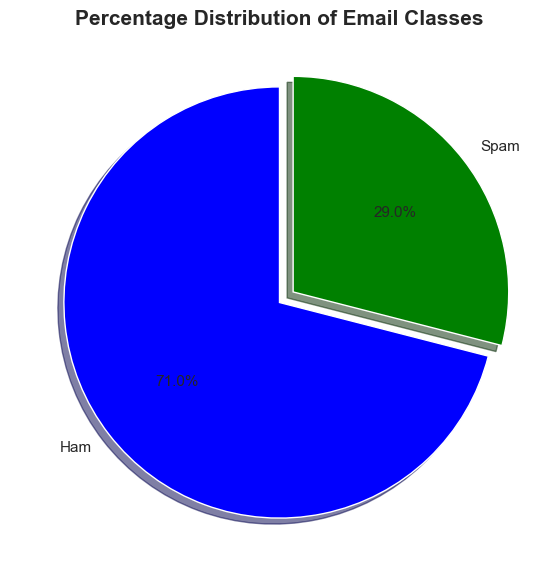

In [19]:
print("Class Distribution\n")

plt.figure(figsize=(7,7))

colors = ["#66BB6A", "#EF5350"]

explode = (0,0.08)

plt.pie(
    target_counts,
    labels=["Ham","Spam"],
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    colors=["Blue", "Green"],
    shadow=True,
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Percentage Distribution of Email Classes",
    fontsize=15,
    fontweight="bold"
)

plt.show()

TOP 20 MOST FREQUENT WORDS



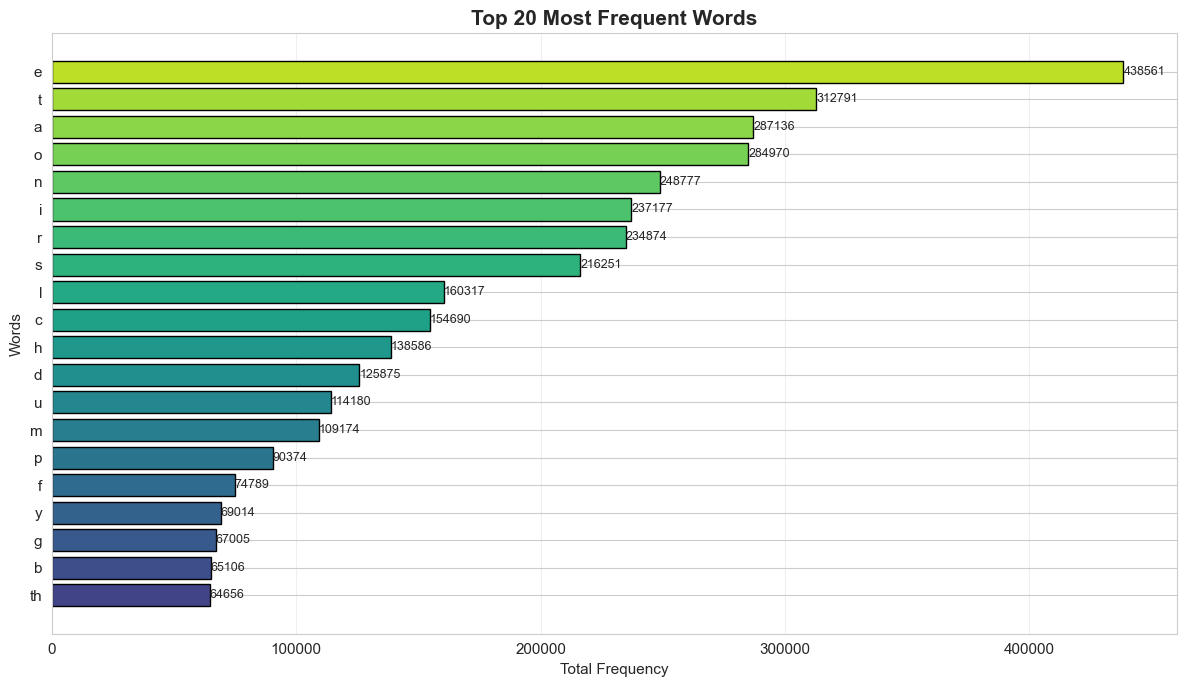

In [23]:
print("TOP 20 MOST FREQUENT WORDS\n")

# Select only numeric word-frequency columns
X_numeric = df.drop(columns="Prediction").select_dtypes(include="number")

# Calculate total frequency of each word
word_frequency = (
    X_numeric
    .sum()
    .sort_values(ascending=False)
)

# Select top 20 words
top20 = word_frequency.head(20)

# Plot
plt.figure(figsize=(12,7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top20)))

bars = plt.barh(
    top20.index[::-1],
    top20.values[::-1],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Top 20 Most Frequent Words",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Total Frequency")
plt.ylabel("Words")
plt.grid(axis="x", alpha=0.3)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

TOP 20 LEAST FREQUENT WORD



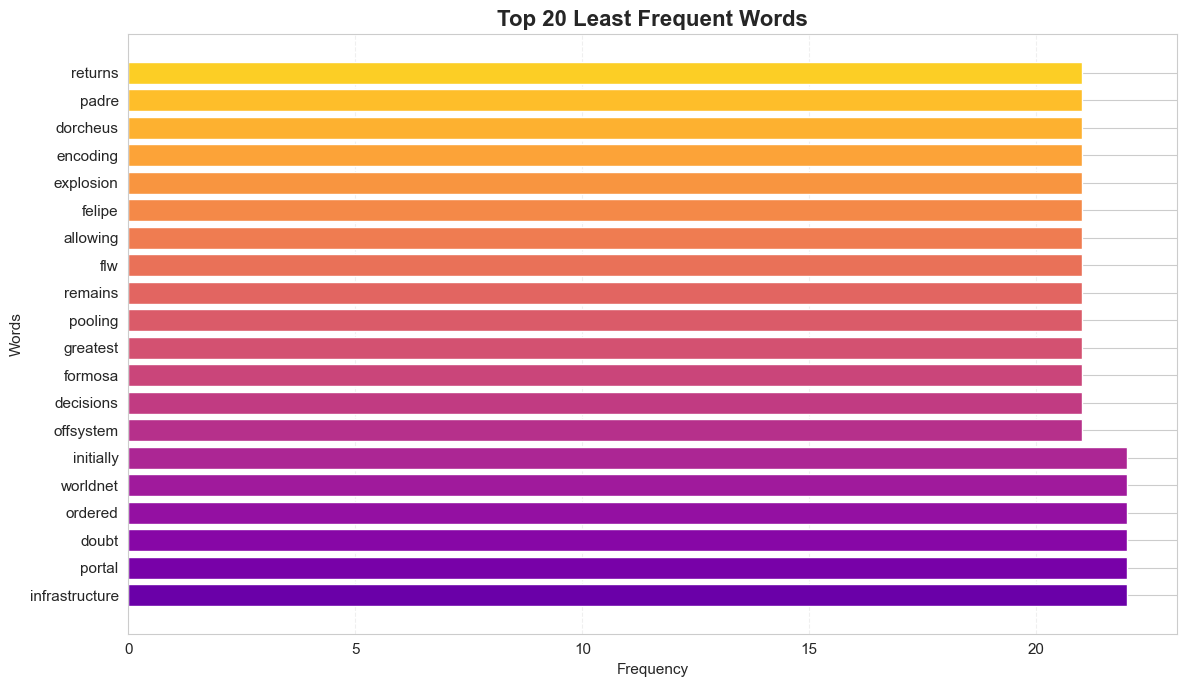

In [24]:
print("TOP 20 LEAST FREQUENT WORD\n")
least20 = word_frequency.tail(20)

plt.figure(figsize=(12,7))

bars = plt.barh(
    least20.index,
    least20.values,
    color=plt.cm.plasma(np.linspace(0.2,0.9,20))
)

plt.title(
    "Top 20 Least Frequent Words",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

TOP WORDS IN SPAM EMAILS



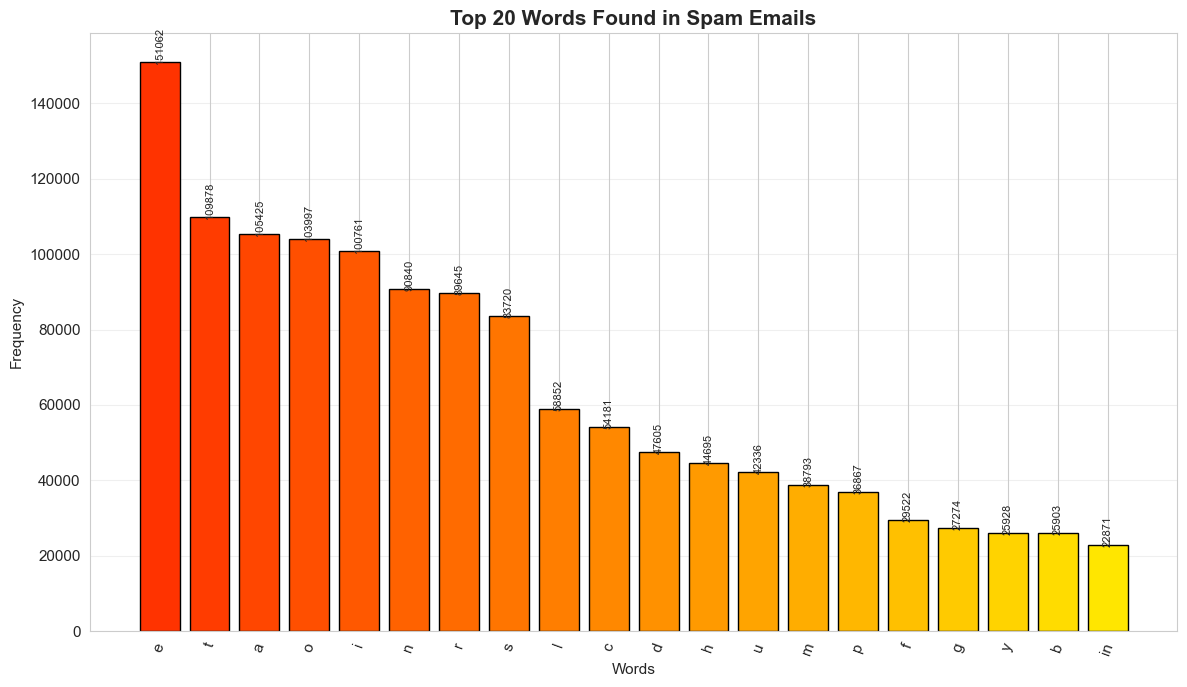

In [26]:
print("TOP WORDS IN SPAM EMAILS\n")

# Select only spam emails
spam_df = df[df["Prediction"] == 1]

# Keep only numeric columns
spam_numeric = (
    spam_df
    .drop(columns="Prediction")
    .select_dtypes(include="number")
)

# Calculate total frequency of each word
spam_words = (
    spam_numeric
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))

colors = plt.cm.autumn(np.linspace(0.2,0.9,len(spam_words)))

bars = plt.bar(
    spam_words.index,
    spam_words.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Top 20 Words Found in Spam Emails",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=70)

plt.grid(axis="y", alpha=0.3)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

TOP 20 WORDS IN HAM EMAILS



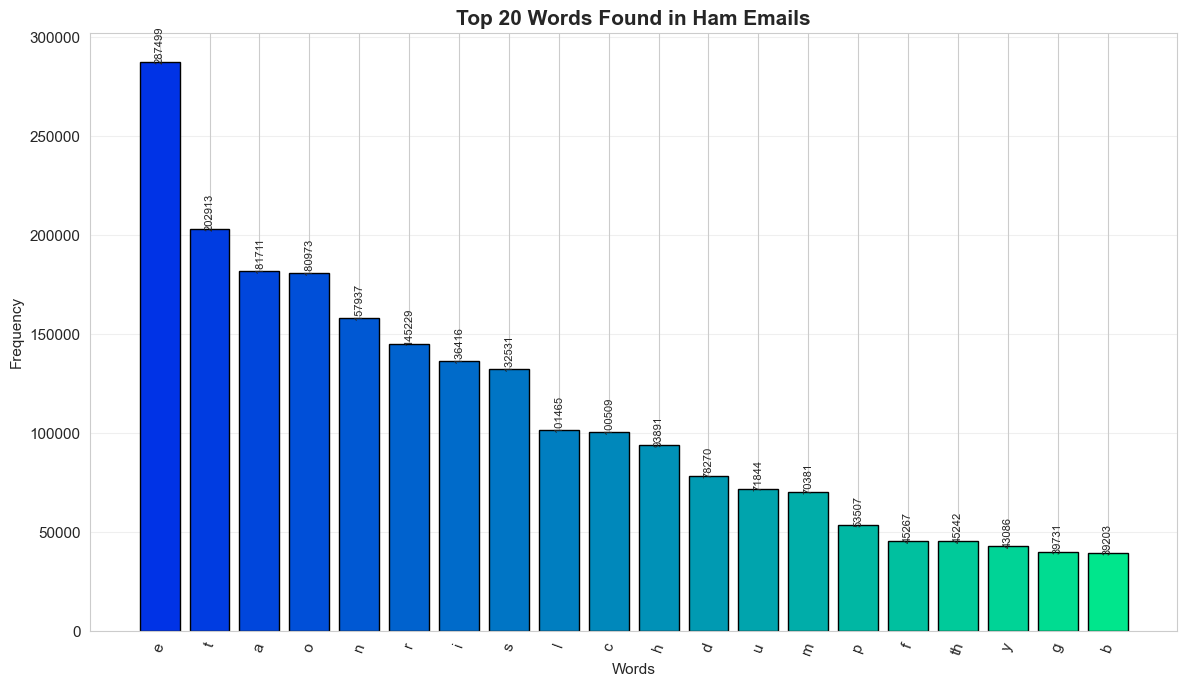

In [28]:
print("TOP 20 WORDS IN HAM EMAILS\n")
ham_df = df[df["Prediction"] == 0]

ham_numeric = (
    ham_df
    .drop(columns="Prediction")
    .select_dtypes(include="number")
)

ham_words = (
    ham_numeric
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))

colors = plt.cm.winter(np.linspace(0.2,0.9,len(ham_words)))

bars = plt.bar(
    ham_words.index,
    ham_words.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Top 20 Words Found in Ham Emails",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=70)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

# Feature Selection

In [31]:
# ============================================================
#               FEATURES & TARGET
# ============================================================

# Remove non-feature columns
X = df.drop(columns=["Email No.", "Prediction"])

# Target
y = df["Prediction"]

print("="*60)
print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)
print("="*60)

# Verify that all features are numeric
print("\nData Types:\n")
print(X.dtypes.value_counts())

Feature Matrix Shape : (5172, 3000)
Target Shape         : (5172,)

Data Types:

int64    3000
Name: count, dtype: int64


In [32]:
# ============================================================
#          CHI-SQUARE FEATURE SELECTION
# ============================================================

from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(
    score_func=chi2,
    k=500
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("="*60)
print("Original Features :", X.shape[1])
print("Selected Features :", X_selected.shape[1])
print("="*60)

Original Features : 3000
Selected Features : 500


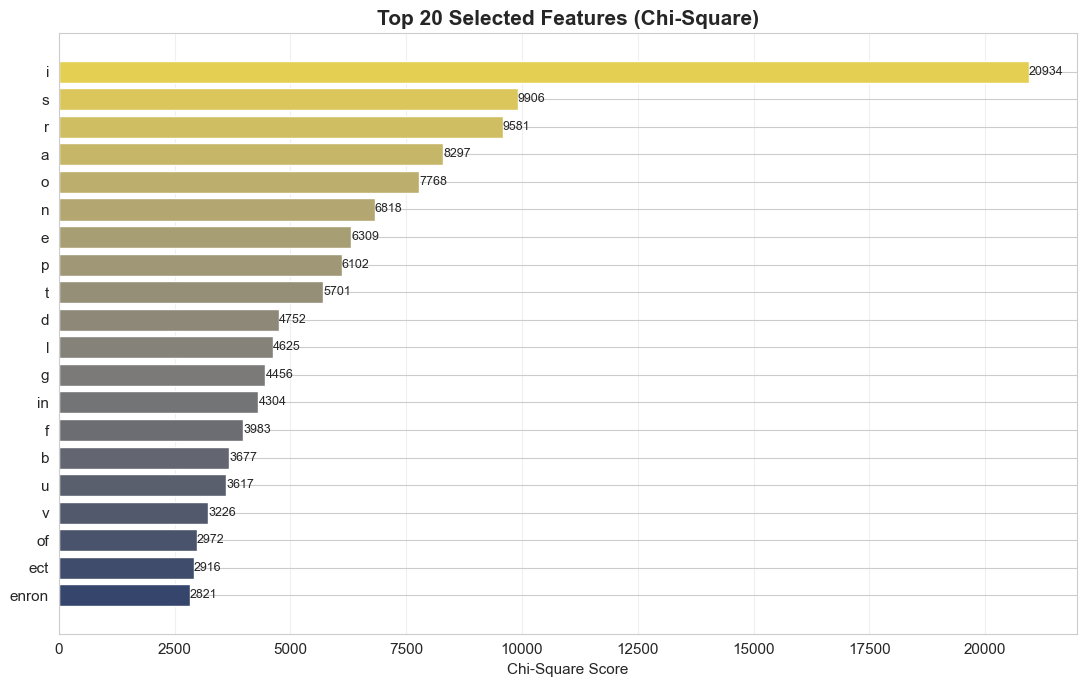

In [33]:
# ============================================================
#          TOP 20 IMPORTANT FEATURES
# ============================================================

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

top20 = scores.head(20)

plt.figure(figsize=(11,7))

bars = plt.barh(
    top20["Feature"][::-1],
    top20["Score"][::-1],
    color=plt.cm.cividis(np.linspace(0.2,0.9,20))
)

plt.title(
    "Top 20 Selected Features (Chi-Square)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Chi-Square Score")

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_width()+5,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

# Model Development

In [34]:
# ============================================================
#                 TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("="*60)

Training Samples : 4137
Testing Samples  : 1035


In [35]:
# ============================================================
#                MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42)
}

In [36]:
# ============================================================
#               MODEL TRAINING
# ============================================================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    results.append({

        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
4,Extra Trees,0.976812,0.960000,0.960000,0.960000
0,Logistic Regression,0.964251,0.928339,0.950000,0.939044
3,Random Forest,0.964251,0.922830,0.956667,0.939444
1,Naive Bayes,0.931401,0.852308,0.923333,0.886400
2,Decision Tree,0.930435,0.880000,0.880000,0.880000


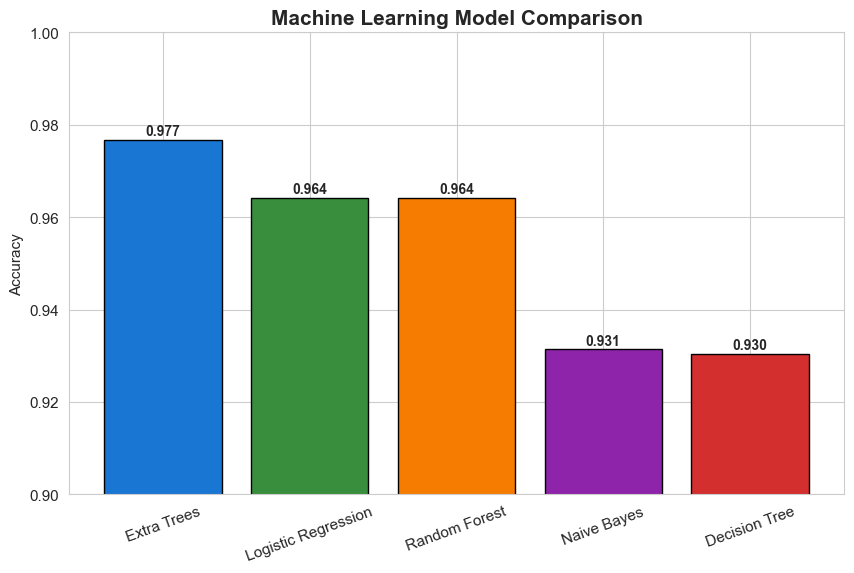

In [37]:
# ============================================================
#             MODEL COMPARISON
# ============================================================

colors = ["#1976D2",
          "#388E3C",
          "#F57C00",
          "#8E24AA",
          "#D32F2F"]

plt.figure(figsize=(10,6))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=colors,
    edgecolor="black"
)

plt.ylim(0.90,1.00)

plt.ylabel("Accuracy")

plt.title(
    "Machine Learning Model Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=20)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.001,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

In [38]:
# ============================================================
#                  BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("="*60)
print(f"Best Performing Model : {best_model_name}")
print("="*60)

best_model = models[best_model_name]

Best Performing Model : Extra Trees


# Model Evaluation

In [39]:
# ============================================================
#              MODEL PERFORMANCE COMPARISON
# ============================================================

from sklearn.metrics import roc_auc_score

performance = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    performance.append({

        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": auc

    })

performance_df = pd.DataFrame(performance)

performance_df = performance_df.sort_values(
    by="Accuracy",
    ascending=False
)

performance_df.reset_index(drop=True, inplace=True)

performance_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Extra Trees,0.976812,0.960000,0.960000,0.960000,0.996771
1,Logistic Regression,0.964251,0.928339,0.950000,0.939044,0.989891
2,Random Forest,0.964251,0.922830,0.956667,0.939444,0.993621
3,Naive Bayes,0.931401,0.852308,0.923333,0.886400,0.969408
4,Decision Tree,0.930435,0.880000,0.880000,0.880000,0.915510


In [40]:
# ============================================================
#              PERFORMANCE TABLE
# ============================================================

performance_df.style\
.background_gradient(cmap="YlGnBu")\
.format({
    "Accuracy":"{:.4f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "F1 Score":"{:.4f}",
    "ROC-AUC":"{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Extra Trees,0.9768,0.9600,0.9600,0.9600,0.9968
1,Logistic Regression,0.9643,0.9283,0.9500,0.9390,0.9899
2,Random Forest,0.9643,0.9228,0.9567,0.9394,0.9936
3,Naive Bayes,0.9314,0.8523,0.9233,0.8864,0.9694
4,Decision Tree,0.9304,0.8800,0.8800,0.8800,0.9155


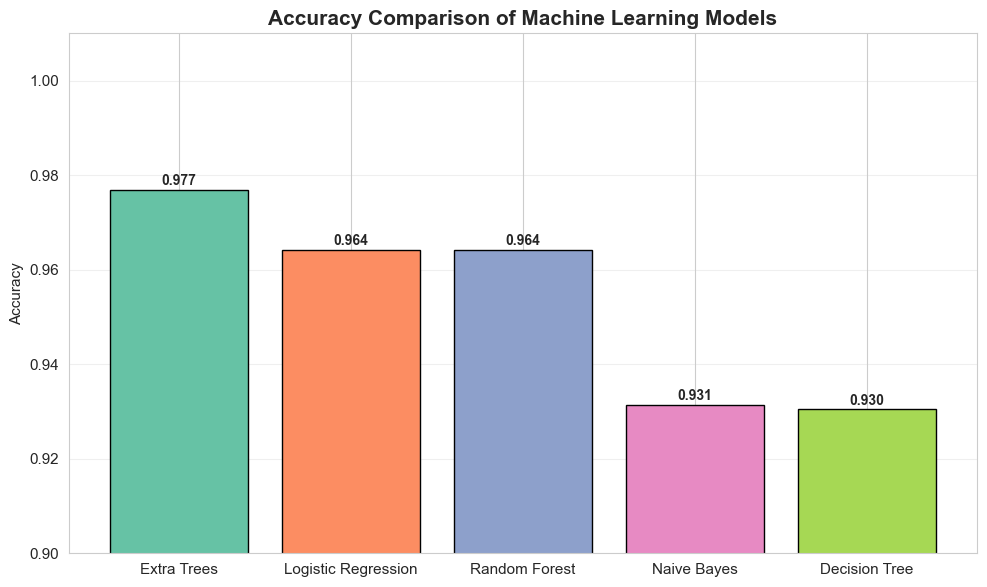

In [41]:
# ============================================================
#                 ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

colors = sns.color_palette("Set2", len(performance_df))

bars = plt.bar(
    performance_df["Model"],
    performance_df["Accuracy"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Accuracy Comparison of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Accuracy")

plt.ylim(0.90,1.01)

plt.grid(axis="y", alpha=0.3)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.001,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

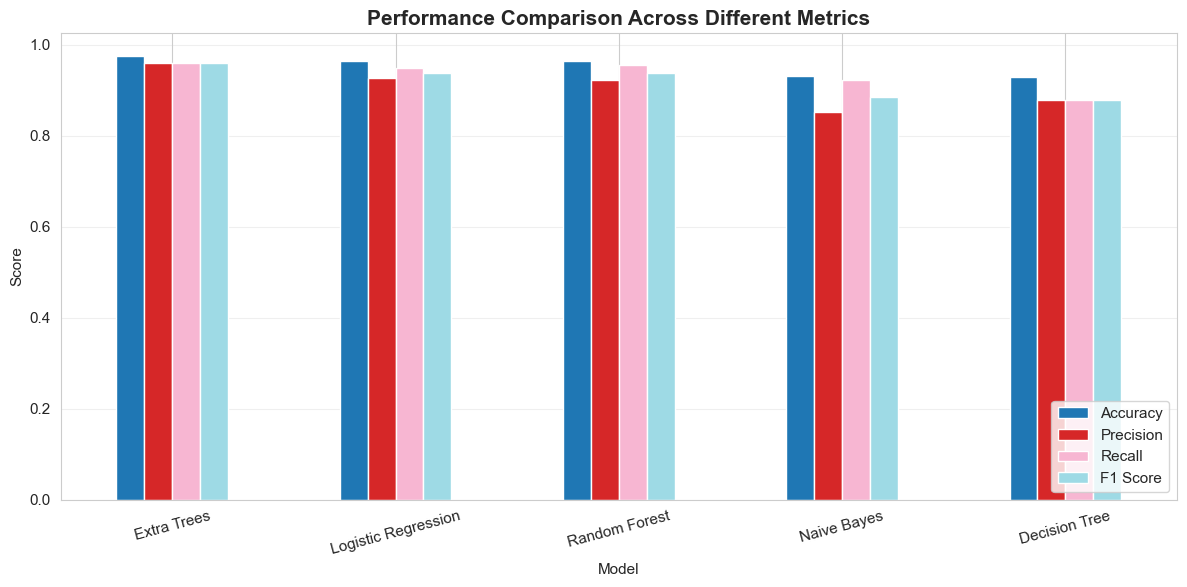

In [42]:
# ============================================================
#           METRIC COMPARISON
# ============================================================

metrics = performance_df.set_index("Model")

metrics[
    ["Accuracy","Precision","Recall","F1 Score"]
].plot(
    kind="bar",
    figsize=(12,6),
    colormap="tab20"
)

plt.title(
    "Performance Comparison Across Different Metrics",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

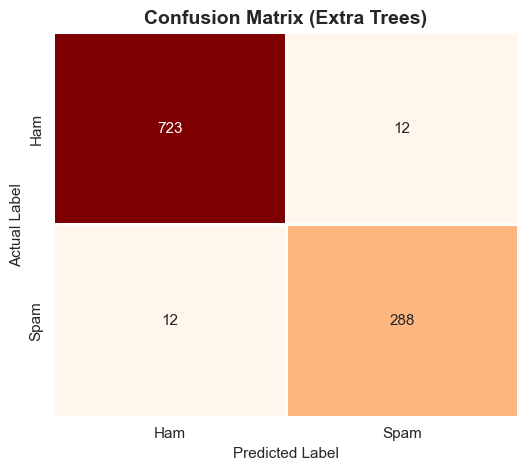

In [43]:
# ============================================================
#               CONFUSION MATRIX
# ============================================================

best_model_name = performance_df.iloc[0]["Model"]

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="OrRd",
    linewidths=1,
    linecolor="white",
    cbar=False,
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.title(
    f"Confusion Matrix ({best_model_name})",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

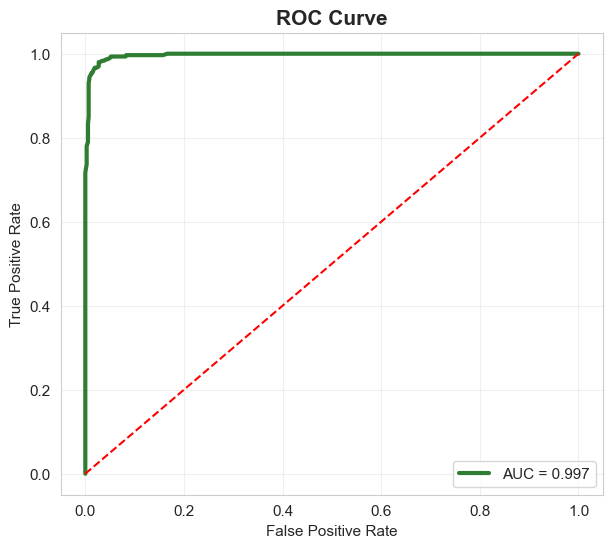

In [44]:
# ============================================================
#                   ROC CURVE
# ============================================================

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        color="#2E7D32",
        linewidth=3,
        label=f"AUC = {auc:.3f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="red"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(
        "ROC Curve",
        fontsize=15,
        fontweight="bold"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

In [27]:
# ============================================================
#             CLASSIFICATION REPORT
# ============================================================

print("="*70)
print("Classification Report")
print("="*70)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       635
           1       0.95      0.94      0.95       292

    accuracy                           0.97       927
   macro avg       0.96      0.96      0.96       927
weighted avg       0.97      0.97      0.97       927



# Save Best Model

In [46]:
# ============================================================
# Save Best Model
# ============================================================

import joblib

joblib.dump(best_model, "spam_classifier.pkl")

print("="*60)
print("Model Saved Successfully")
print("="*60)
print(f"Best Model : {best_model_name}")
print("File Name  : spam_classifier.pkl")
print("="*60)

Model Saved Successfully
Best Model : Extra Trees
File Name  : spam_classifier.pkl


In [47]:
# ============================================================
# Load Saved Model
# ============================================================

loaded_model = joblib.load("spam_classifier.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.ExtraTreesClassifier'>


In [48]:
# ============================================================
# Test Saved Model
# ============================================================

sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

prediction = loaded_model.predict(sample)[0]

print("="*60)

print("Actual Label    :", actual)

print("Predicted Label :", prediction)

print("="*60)

Actual Label    : 0
Predicted Label : 0


In [49]:
# ============================================================
# Human Readable Prediction
# ============================================================

sample = X_test.iloc[[5]]

prediction = loaded_model.predict(sample)[0]

print("="*60)

if prediction == 1:
    print("Prediction : SPAM EMAIL")
else:
    print("Prediction : HAM EMAIL")

print("="*60)

Prediction : SPAM EMAIL


In [50]:
# ============================================================
# Prediction Probability
# ============================================================

if hasattr(loaded_model, "predict_proba"):

    probability = loaded_model.predict_proba(sample)[0]

    print(f"Ham Probability  : {probability[0]:.4f}")
    print(f"Spam Probability : {probability[1]:.4f}")

Ham Probability  : 0.2400
Spam Probability : 0.7600


In [51]:
# ============================================================
# Test Multiple Samples
# ============================================================

random_samples = X_test.sample(10, random_state=42)

predictions = loaded_model.predict(random_samples)

actual = y_test.loc[random_samples.index]

results = pd.DataFrame({
    "Actual": actual.values,
    "Predicted": predictions
})

results["Status"] = np.where(
    results["Actual"] == results["Predicted"],
    "Correct",
    "Wrong"
)

results

,Actual,Predicted,Status
0,0,0,Correct
1,1,1,Correct
2,0,0,Correct
3,0,0,Correct
4,0,0,Correct
5,0,0,Correct
6,0,0,Correct
7,0,0,Correct
8,0,0,Correct
9,0,0,Correct
